# 04 — Customer Value Segmentation

**Objective:** Segment customers using an RFM-adapted framework to identify high-value, at-risk, and growth-opportunity customer groups. Provide targeted marketing and retention strategies.

---

## 1. Setup & Data Preparation

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from src.config import COLORS, CATEGORY_PALETTE, FIGURES_PATH, DATA_PATH
from src.data_cleaning import load_raw_data, clean_data
from src.feature_engineering import add_features
from src.viz_style import set_theme, format_axis_currency, GOLD_CMAP

set_theme()

raw = load_raw_data(DATA_PATH)
df = clean_data(raw)
df = add_features(df)

# Focus on non-canceled bookings
active = df[df['is_canceled'] == 0].copy()
print(f'Active bookings: {len(active):,}')

Active bookings: 75,165


## 2. RFM-Adapted Feature Construction

Traditional RFM adapted for hotel context:
- **Recency (R):** Inverse of lead time — shorter lead time = more recent/engaged
- **Frequency (F):** Repeat guest flag + previous bookings not canceled
- **Monetary (M):** Total revenue per booking

In [2]:
# Build RFM features per booking
rfm = active[['lead_time', 'is_repeated_guest', 'previous_bookings_not_canceled',
               'total_revenue', 'adr', 'total_nights', 'total_of_special_requests',
               'market_segment', 'hotel', 'customer_type']].copy()

# Recency: inverse lead time (cap at 365)
rfm['recency_score'] = 1 / (1 + rfm['lead_time'].clip(upper=365) / 365)

# Frequency: combined loyalty signal
rfm['frequency_score'] = rfm['is_repeated_guest'] + rfm['previous_bookings_not_canceled'].clip(upper=10)

# Monetary: total revenue
rfm['monetary_score'] = rfm['total_revenue']

rfm.describe().round(2)

,lead_time,is_repeated_guest,previous_bookings_not_canceled,total_revenue,adr,total_nights,total_of_special_requests,recency_score,frequency_score,monetary_score
count,75165.00,75165.00,75165.00,75165.00,75165.00,75165.00,75165.00,75165.00,75165.00,75165.00
mean,79.98,0.04,0.20,345.86,99.99,3.39,0.71,0.85,0.19,345.86
std,91.11,0.20,1.81,322.85,49.21,2.58,0.83,0.14,1.09,322.85
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.50,0.00,0.00
25%,9.00,0.00,0.00,138.50,67.50,2.00,0.00,0.75,0.00,138.50
50%,45.00,0.00,0.00,259.20,92.50,3.00,1.00,0.89,0.00,259.20
75%,124.00,0.00,0.00,440.00,125.00,4.00,1.00,0.98,0.00,440.00
max,737.00,1.00,72.00,7590.00,510.00,69.00,5.00,1.00,11.00,7590.00


## 3. K-Means Clustering

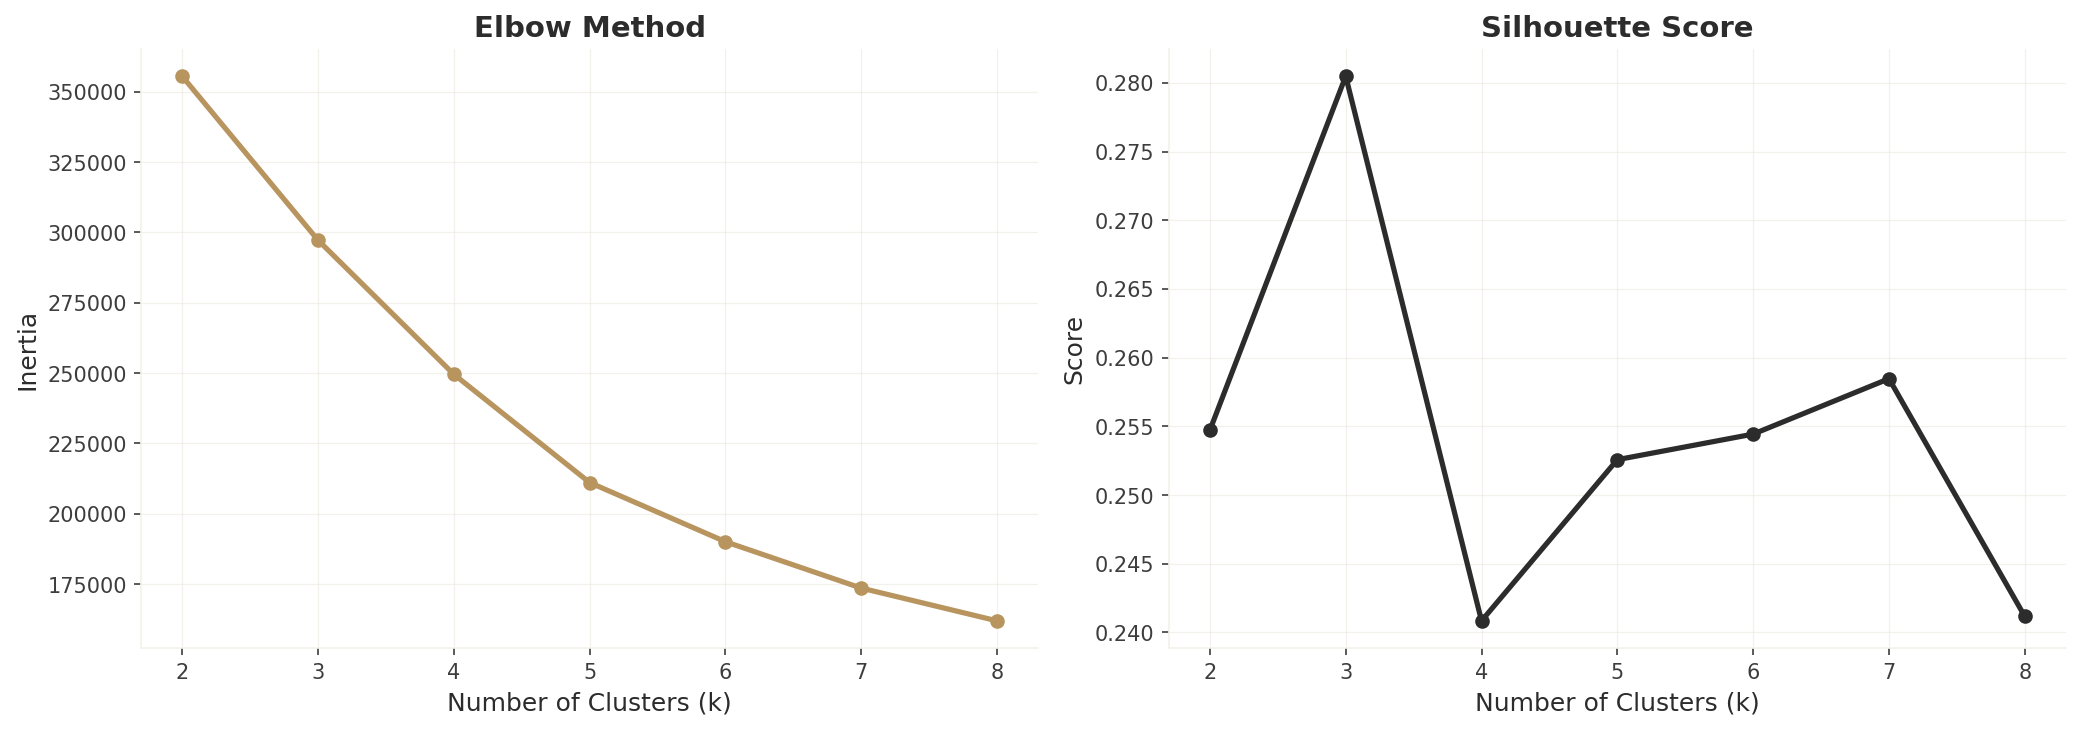

Silhouette scores: {2: '0.255', 3: '0.280', 4: '0.241', 5: '0.253', 6: '0.254', 7: '0.258', 8: '0.241'}


In [3]:
# Features for clustering
cluster_features = ['recency_score', 'frequency_score', 'monetary_score',
                    'adr', 'total_nights', 'total_of_special_requests']

X_cluster = rfm[cluster_features].fillna(0)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=10000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, marker='o', color=COLORS['primary'], linewidth=2.5)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o', color=COLORS['dark'], linewidth=2.5)
axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}19_elbow_silhouette.png')
plt.show()

print('Silhouette scores:', {k: f'{s:.3f}' for k, s in zip(K_range, sil_scores)})

In [4]:
# Fit final model with k=4
k_optimal = 4
km_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(X_scaled)

print(f'Cluster distribution:')
print(rfm['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0    22545
1    11463
2    39834
3     1323
Name: count, dtype: int64


## 4. Segment Profiling

In [5]:
# Cluster profiles
profile = rfm.groupby('cluster').agg(
    avg_recency=('recency_score', 'mean'),
    avg_frequency=('frequency_score', 'mean'),
    avg_revenue=('monetary_score', 'mean'),
    avg_adr=('adr', 'mean'),
    avg_nights=('total_nights', 'mean'),
    avg_special_requests=('total_of_special_requests', 'mean'),
    count=('adr', 'count')
).round(2)

profile['pct'] = (profile['count'] / profile['count'].sum() * 100).round(1)

# Assign segment names based on profile characteristics
# Sort by avg_revenue to assign names
revenue_rank = profile['avg_revenue'].rank(ascending=False)
segment_names = {}
for cluster_id in profile.index:
    rank = revenue_rank[cluster_id]
    freq = profile.loc[cluster_id, 'avg_frequency']
    if rank == 1:
        segment_names[cluster_id] = 'High-Value'
    elif rank == 2:
        segment_names[cluster_id] = 'Mid-Value Engaged'
    elif freq > profile['avg_frequency'].median():
        segment_names[cluster_id] = 'Loyal Budget'
    else:
        segment_names[cluster_id] = 'Budget Transient'

profile['segment'] = profile.index.map(segment_names)
rfm['segment'] = rfm['cluster'].map(segment_names)

profile

,avg_recency,avg_frequency,avg_revenue,avg_adr,avg_nights,avg_special_requests,count,pct,segment
cluster,,,,,,,,,
0,0.69,0.01,325.29,91.63,3.80,0.70,22545,30.0,Mid-Value Engaged
1,0.82,0.03,918.28,157.57,6.58,1.16,11463,15.3,High-Value
2,0.94,0.11,200.82,89.51,2.30,0.59,39834,53.0,Loyal Budget
3,0.97,7.34,103.42,59.14,1.66,0.81,1323,1.8,Loyal Budget


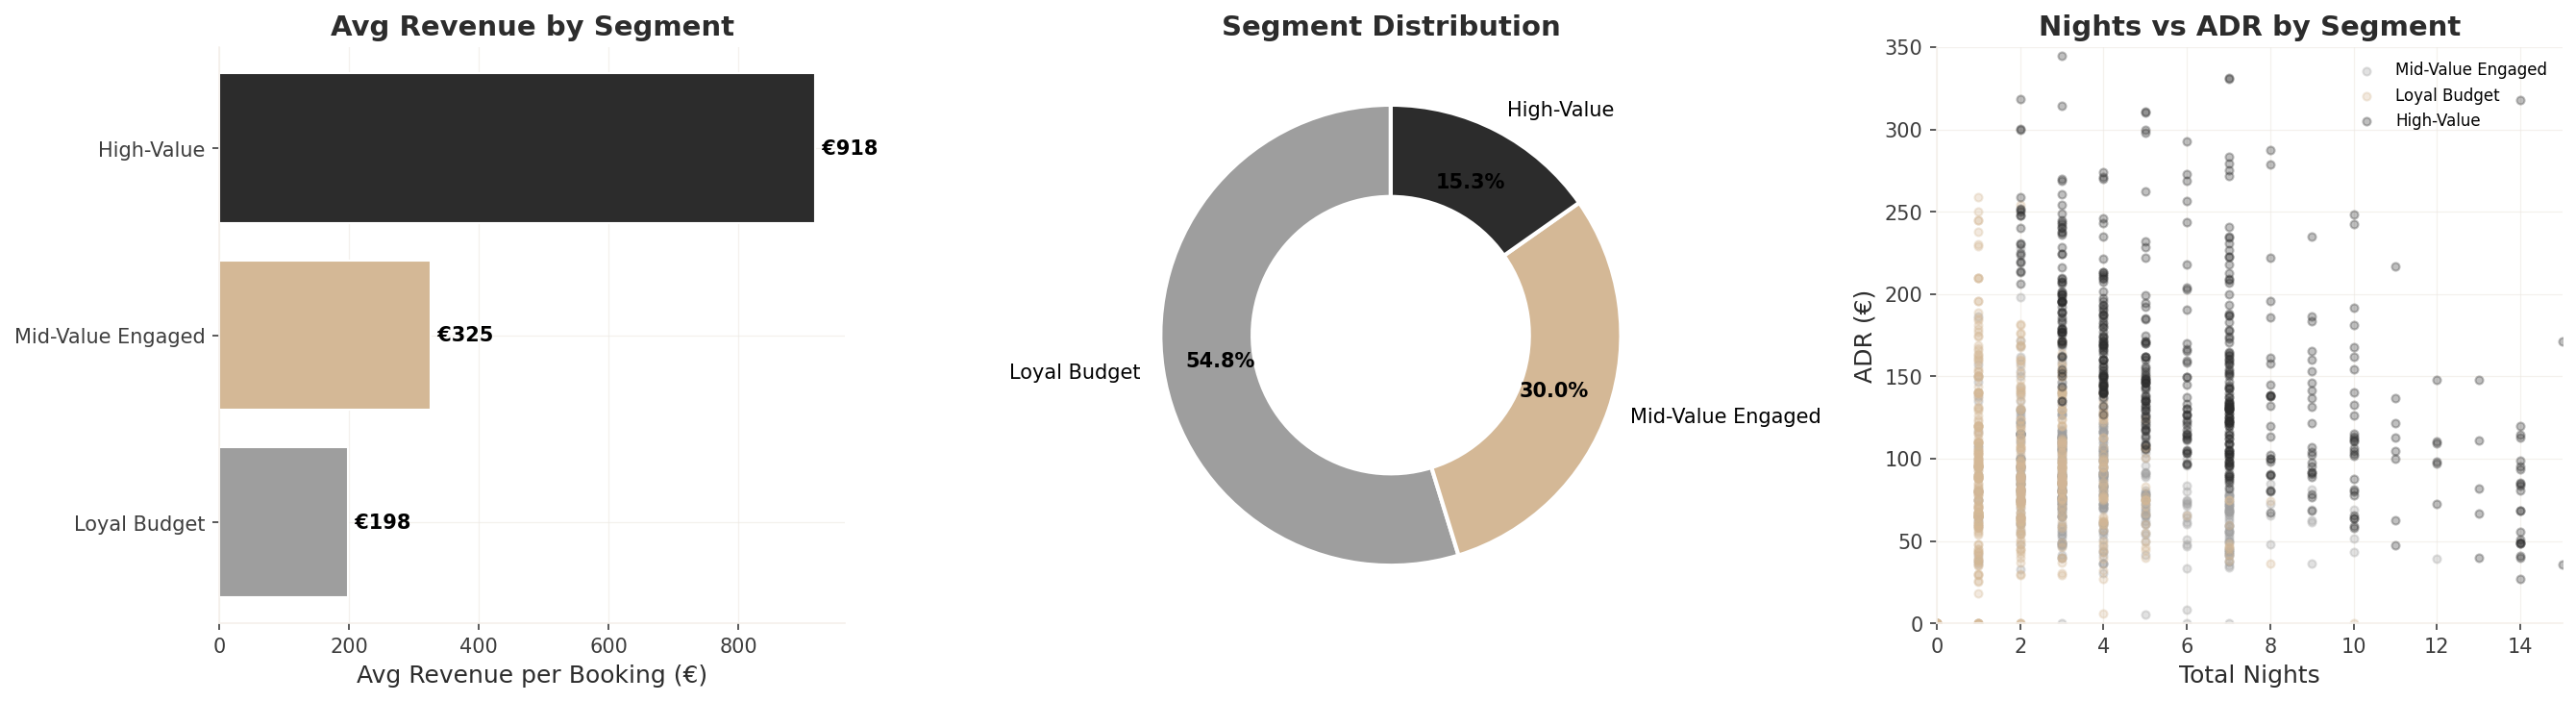

In [6]:
# Radar chart for segment comparison
from matplotlib.patches import FancyBboxPatch

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 4.1 — Revenue distribution by segment
ax = axes[0]
seg_rev = rfm.groupby('segment')['monetary_score'].mean().sort_values(ascending=True)
colors_seg = [COLORS['muted'], COLORS['accent'], COLORS['dark'], COLORS['primary']]
bars = ax.barh(seg_rev.index, seg_rev.values, color=colors_seg[:len(seg_rev)], edgecolor='white')
for bar in bars:
    w = bar.get_width()
    ax.text(w, bar.get_y() + bar.get_height()/2, f' €{w:.0f}',
            ha='left', va='center', fontsize=10, fontweight='bold')
ax.set_title('Avg Revenue by Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Revenue per Booking (€)')

# 4.2 — Segment size (donut)
ax = axes[1]
seg_count = rfm['segment'].value_counts()
wedges, texts, autotexts = ax.pie(
    seg_count.values, labels=seg_count.index,
    autopct='%1.1f%%', colors=colors_seg[:len(seg_count)],
    startangle=90, pctdistance=0.75,
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
ax.set_title('Segment Distribution', fontsize=14, fontweight='bold')

# 4.3 — ADR vs Nights by segment
ax = axes[2]
for i, seg in enumerate(rfm['segment'].unique()):
    mask = rfm['segment'] == seg
    sample = rfm[mask].sample(min(500, mask.sum()), random_state=42)
    ax.scatter(sample['total_nights'], sample['adr'],
               alpha=0.3, s=15, label=seg, color=colors_seg[i % len(colors_seg)])
ax.set_title('Nights vs ADR by Segment', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Nights')
ax.set_ylabel('ADR (€)')
ax.set_xlim(0, 15)
ax.set_ylim(0, 350)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}20_segment_profiles.png')
plt.show()

## 5. Segment Behavior Deep Dive

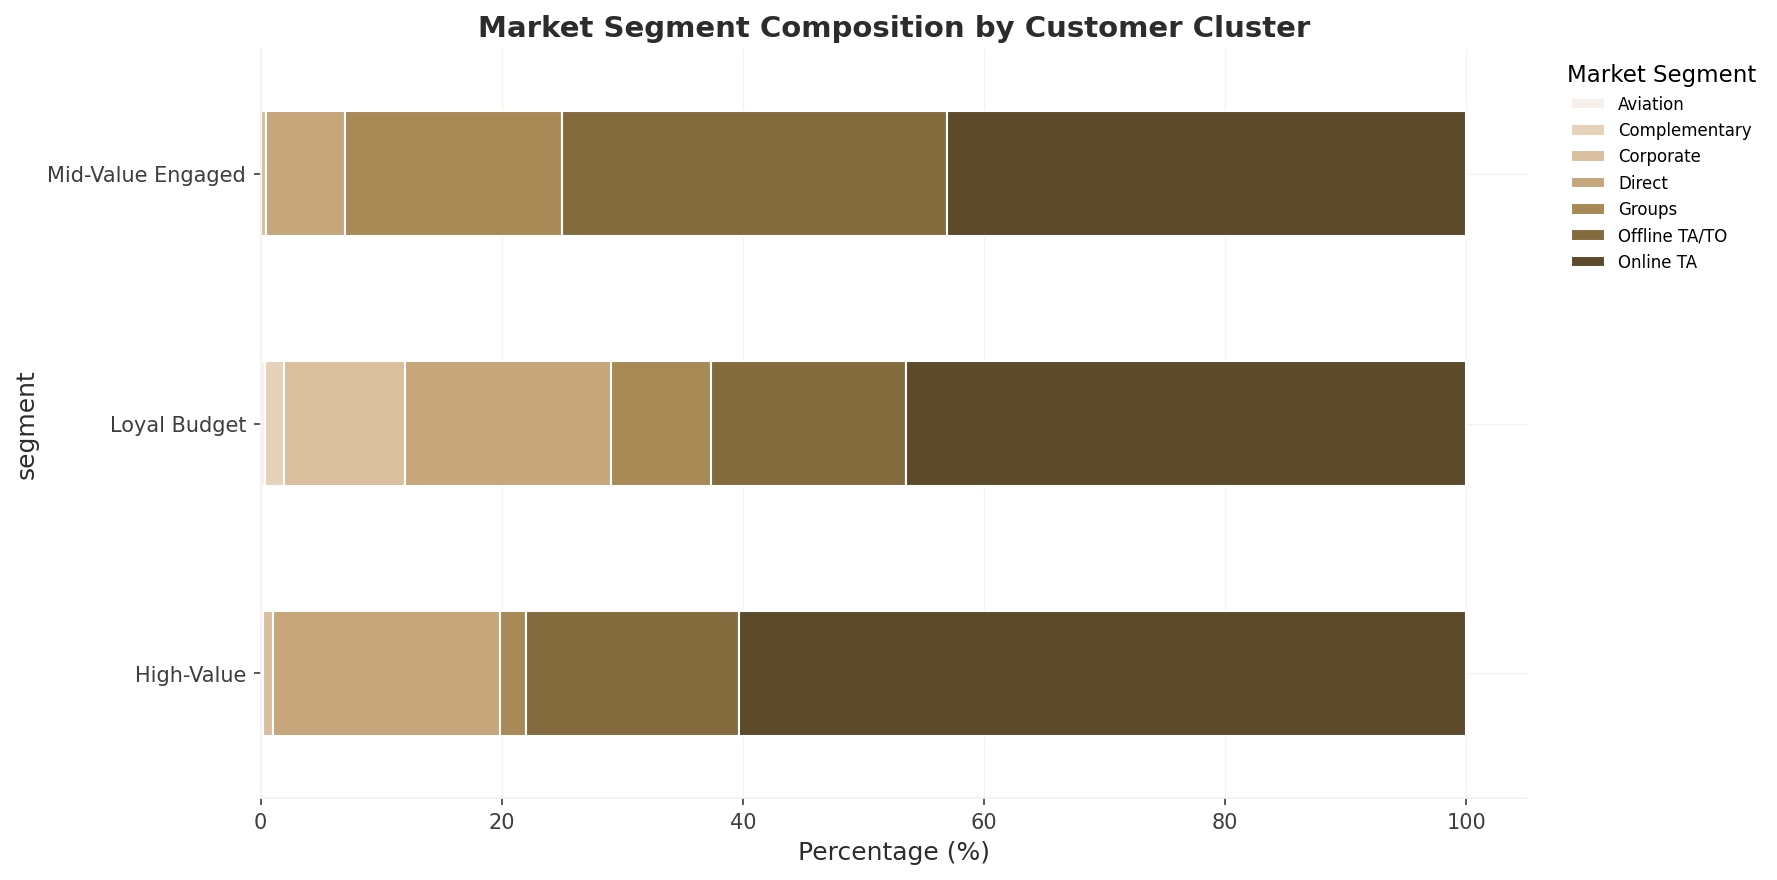

In [7]:
# Market segment composition per cluster
seg_market = pd.crosstab(rfm['segment'], rfm['market_segment'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
seg_market.plot(kind='barh', stacked=True, ax=ax, colormap=GOLD_CMAP, edgecolor='white')
ax.set_title('Market Segment Composition by Customer Cluster', fontsize=14, fontweight='bold')
ax.set_xlabel('Percentage (%)')
ax.legend(title='Market Segment', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}21_segment_composition.png')
plt.show()

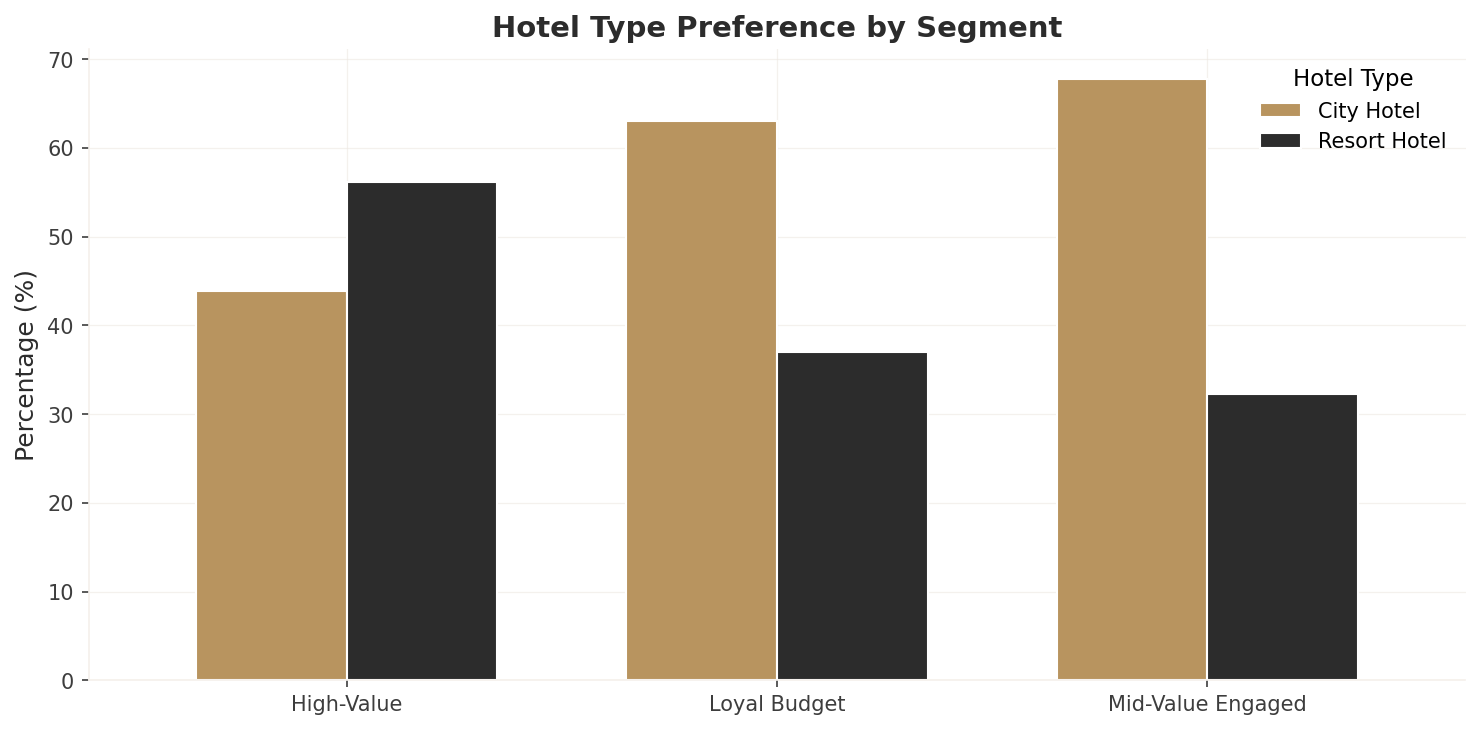

In [8]:
# Hotel type preference by segment
seg_hotel = pd.crosstab(rfm['segment'], rfm['hotel'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 5))
seg_hotel.plot(kind='bar', ax=ax, color=[COLORS['primary'], COLORS['dark']],
               edgecolor='white', width=0.7)
ax.set_title('Hotel Type Preference by Segment', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Hotel Type')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}22_segment_hotel_pref.png')
plt.show()

## 6. Strategic Recommendations by Segment

| Segment | Profile | Strategy |
|---------|---------|----------|
| **High-Value** | Long stays, high ADR, special requests | VIP loyalty program, personalized upselling, dedicated service |
| **Mid-Value Engaged** | Moderate ADR, engaged (special requests), mix of business/leisure | Targeted upgrade offers, early check-in perks, loyalty incentives |
| **Loyal Budget** | Repeat guests, lower ADR, shorter stays | Reward repeat behavior, bundle deals, referral program |
| **Budget Transient** | Low ADR, short stays, mostly OTA channel | Win-back campaigns, direct booking incentives, flash sale targeting |

### Revenue Optimization
1. **Focus retention on High-Value segment** — even small improvements in retention yield significant revenue impact.
2. **Upgrade Mid-Value to High-Value** — these customers show engagement signals (special requests); nurture with targeted offers.
3. **Convert Budget Transient to direct bookers** — reduce OTA commission costs through loyalty program enrollment.

---
*Project complete. See [README.md](../README.md) for project overview and key findings.*